In [146]:
import os
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.utils import load_json_file

from pathlib import Path

import utils.comparison_utils as comparison_utils
importlib.reload(comparison_utils)

load_split_metadata = comparison_utils.load_split_metadata
load_split_summary = comparison_utils.load_split_summary
get_bad_cases = comparison_utils.get_bad_cases
load_ia_results_for_comparison = comparison_utils.load_ia_results_for_comparison
load_math_results_for_comparison = comparison_utils.load_math_results_for_comparison
build_comparison_agg_df = comparison_utils.build_comparison_agg_df
plot_comparison_bar_by_resolution = comparison_utils.plot_comparison_bar_by_resolution

SPLIT_PATHS_BY_RESOLUTION = {
    "mid_res": {
        "train": "../output/segmentation/8.final_results/mid_res/2026-03-05_15-35-52",
        "val": "../output/segmentation/8.final_results/mid_res/2026-03-27_08-43-09",
        "test": "../output/segmentation/8.final_results/mid_res/2026-03-30_20-48-16",
    },
    "high_res": {
        "train": "../output/segmentation/8.final_results/high_res/2026-03-23_14-24-53",
        "val": "../output/segmentation/8.final_results/high_res/2026-03-20_20-41-26",
        "test": "../output/segmentation/8.final_results/high_res/2026-04-04_10-01-42",
    },
}

VALID_SPLITS = ("train", "val", "test")
SUCCESS_STATUS = ["ambos toleráveis", "ambos corretos"]

# Resultados Testes

## Carregamento de dados

Nesta seção ficam todas as células de carregamento dos datasets de validação e dos casos ruins.

In [140]:

IA_RESULTS_BASE = Path("../output/ia_results")
MATH_TEST_SUMMARY_PATHS = {
    "mid_res": Path("../output/segmentation/8.final_results/mid_res/2026-03-30_20-48-16/ostios_test_summary.csv"),
    "high_res": Path("../output/segmentation/8.final_results/high_res/2026-04-04_10-01-42/ostios_test_summary.csv"),
}

ia_results_df, missing_ia_files = load_ia_results_for_comparison(IA_RESULTS_BASE)
math_results_df, missing_math_files = load_math_results_for_comparison(MATH_TEST_SUMMARY_PATHS)
comparison_raw_df = pd.concat([ia_results_df, math_results_df], ignore_index=True)
comparison_agg_df = build_comparison_agg_df(comparison_raw_df)

print("Shapes carregados para comparação IA:")
print("- IA:", ia_results_df.shape)
print("- Matemático:", math_results_df.shape)
print("- Consolidado:", comparison_raw_df.shape)
print("- Agregado:", comparison_agg_df.shape)

if missing_ia_files:
    print("\nAvisos IA:")
    for msg in missing_ia_files:
        print("-", msg)

if missing_math_files:
    print("\nAvisos Matemático:")
    for msg in missing_math_files:
        print("-", msg)

Shapes carregados para comparação IA:
- IA: (1400, 7)
- Matemático: (1090, 7)
- Consolidado: (2490, 7)
- Agregado: (9, 12)


### Dados para comparação com métodos de IA

Nesta subseção são carregados e agregados os dados necessários para os gráficos de comparação IA vs método matemático (teste).

### Dados de validação (30, 60 e 90 imagens)

In [116]:
path_60_val_tests = "../output/segmentation/5.val_diff/2026-03-08_15-43-56"
path_90_val_tests = "../output/segmentation/5.val_diff/2026-03-08_18-48-56"
path_30_val_tests = "../output/segmentation/8.final_results/mid_res/2026-03-27_08-43-09"

json_file_name = "ostios_val_metadata.json"
csv_file_name = "ostios_val_summary.csv"

paths_val_tests = [path_30_val_tests, path_60_val_tests, path_90_val_tests]
num_tests = [30, 60, 90]

dict_val_tests = {}

for path, num in zip(paths_val_tests, num_tests):
    json_path = os.path.join(path, json_file_name)
    csv_path = os.path.join(path, csv_file_name)

    json_data = load_json_file(json_path)
    csv_data = pd.read_csv(csv_path)

    dict_val_tests[num] = {
        "json": json_data,
        "csv": csv_data,
    }

    print("Percentual de óstios detectados para {} imagens: {}".format(num, json_data["results_summary"]["total_success_percent"]))
    print("Dice médio para {} imagens: {}".format(num, json_data["results_summary"]["dice_artery_mean"]))
    print()

Percentual de óstios detectados para 30 imagens: 93.33333333333333
Dice médio para 30 imagens: 0.6510994123228695

Percentual de óstios detectados para 60 imagens: 85.0
Dice médio para 60 imagens: 0.634258141192984

Percentual de óstios detectados para 90 imagens: 86.66666666666667
Dice médio para 90 imagens: 0.6347419572961731



### Dados dos casos ruins (bad_tests)

In [117]:
bad_cases_split = "test"  # opcoes: "train", "val" ou "test"

if bad_cases_split not in VALID_SPLITS:
    raise ValueError("bad_cases_split deve ser 'train', 'val' ou 'test'.")

if bad_cases_split not in SPLIT_PATHS_BY_RESOLUTION["mid_res"]:
    raise ValueError(f"Split '{bad_cases_split}' nao disponivel para mid_res.")
if bad_cases_split not in SPLIT_PATHS_BY_RESOLUTION["high_res"]:
    print(f"Aviso: split '{bad_cases_split}' nao disponivel para high_res. Sera exibido apenas mid_res.")

df_mid_res = load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", bad_cases_split)
df_mid_bad_res = get_bad_cases(df_mid_res)

bad_summary_rows = [
    {
        "resolucao": "mid_res",
        "split": bad_cases_split,
        "total_casos": int(df_mid_res.shape[0]),
        "casos_ruins": int(df_mid_bad_res.shape[0]),
        "percentual_ruins": 100 * df_mid_bad_res.shape[0] / df_mid_res.shape[0],
    }
]

df_high_res = load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", bad_cases_split)
if df_high_res is not None:
    df_high_bad_res = get_bad_cases(df_high_res)
    bad_summary_rows.append(
        {
            "resolucao": "high_res",
            "split": bad_cases_split,
            "total_casos": int(df_high_res.shape[0]),
            "casos_ruins": int(df_high_bad_res.shape[0]),
            "percentual_ruins": 100 * df_high_bad_res.shape[0] / df_high_res.shape[0],
        }
    )
else:
    df_high_res = pd.DataFrame(columns=df_mid_res.columns)
    df_high_bad_res = pd.DataFrame(columns=df_mid_bad_res.columns)

bad_summary_df = pd.DataFrame(bad_summary_rows)

display(bad_summary_df)
print("Split de casos ruins selecionado:", bad_cases_split)
print("Mid Res Shape:", df_mid_res.shape)
print("Mid Res Bad Results Shape:", df_mid_bad_res.shape)
if not df_high_res.empty:
    print("High Res Shape:", df_high_res.shape)
    print("High Res Bad Results Shape:", df_high_bad_res.shape)

,resolucao,split,total_casos,casos_ruins,percentual_ruins
0,mid_res,test,700,137,19.571429
1,high_res,test,700,227,32.428571


Split de casos ruins selecionado: test
Mid Res Shape: (700, 17)
Mid Res Bad Results Shape: (137, 17)
High Res Shape: (700, 17)
High Res Bad Results Shape: (227, 17)


### Dados de train, test e validação

In [118]:
subset_rows = []
for resolution, split_paths in SPLIT_PATHS_BY_RESOLUTION.items():
    for subset_name in VALID_SPLITS:
        metadata = load_split_metadata(SPLIT_PATHS_BY_RESOLUTION, resolution, subset_name)
        if metadata is None:
            subset_rows.append(
                {
                    "subset": subset_name,
                    "resolucao": resolution,
                    "num_imagens": np.nan,
                    "dice_medio": np.nan,
                    "tempo_execucao_min": np.nan,
                    "sucesso_total_percent": np.nan,
                    "ostios_sucesso_total": np.nan,
                    "disponivel": False,
                }
            )
            continue

        results_summary = metadata.get("results_summary", {})
        execution_info = metadata.get("execution_info", {})
        execution_time_seconds = execution_info.get("execution_time_seconds", np.nan)
        num_imagens = execution_info.get("num_images", np.nan)
        success_total_percent = results_summary.get("total_success_percent", np.nan)
        if pd.isna(success_total_percent):
            both_correct = results_summary.get("both_correct_percent", 0)
            both_tolerable = results_summary.get("both_tolerable_percent", 0)
            success_total_percent = both_correct + both_tolerable

        if pd.notna(num_imagens) and pd.notna(success_total_percent):
            ostios_sucesso_total = (num_imagens * 2) * (success_total_percent / 100)
        else:
            ostios_sucesso_total = np.nan

        subset_rows.append(
            {
                "subset": subset_name,
                "resolucao": resolution,
                "num_imagens": num_imagens,
                "dice_medio": results_summary.get("dice_artery_mean", np.nan),
                "tempo_execucao_min": execution_time_seconds / 60 if pd.notna(execution_time_seconds) else np.nan,
                "sucesso_total_percent": success_total_percent,
                "ostios_sucesso_total": ostios_sucesso_total,
                "disponivel": True,
            }
        )

subset_summary_df = pd.DataFrame(subset_rows)
subset_summary_df["subset"] = pd.Categorical(subset_summary_df["subset"], categories=list(VALID_SPLITS), ordered=True)
subset_summary_df = subset_summary_df.sort_values(["subset", "resolucao"])

display(subset_summary_df)

missing_rows = subset_summary_df[~subset_summary_df["disponivel"]]
if not missing_rows.empty:
    print("Combinacoes sem dados:")
    display(missing_rows[["subset", "resolucao"]])

,subset,resolucao,num_imagens,dice_medio,tempo_execucao_min,sucesso_total_percent,ostios_sucesso_total,disponivel
3,train,high_res,270,0.566495,1903.192395,65.925926,356.0,True
0,train,mid_res,270,0.614006,369.559395,88.148148,476.0,True
4,val,high_res,30,0.571140,236.837366,86.666667,52.0,True
1,val,mid_res,30,0.651099,49.648786,93.333333,56.0,True
5,test,high_res,700,0.550288,5070.273159,71.428571,1000.0,True
2,test,mid_res,700,0.607369,1014.096081,84.285714,1180.0,True


### Dados dos métodos de downscale

In [119]:
downscale_base_path = "../output/segmentation/1.downscale_method"
downscale_folders = sorted(
    [
        folder
        for folder in os.listdir(downscale_base_path)
        if os.path.isdir(os.path.join(downscale_base_path, folder))
    ]
)

downscale_rows = []
for folder in downscale_folders:
    metadata_path = os.path.join(downscale_base_path, folder, "ostios_val_metadata.json")
    if not os.path.exists(metadata_path):
        continue

    metadata = load_json_file(metadata_path)

    preprocessing = metadata.get("preprocessing_config", {})
    results = metadata.get("results_summary", {})
    execution = metadata.get("execution_info", {})

    method = preprocessing.get("downscale_method", "unknown")
    interpolation = preprocessing.get("opencv_interpolation")

    if method == "scipy":
        method_label = "SciPy (NDI)"
    else:
        interp_label = str(interpolation).upper() if interpolation else "N/A"
        method_label = f"OpenCV ({interp_label})"

    success_total_percent = results.get("total_success_percent")
    if success_total_percent is None:
        success_total_percent = results.get("both_correct_percent", 0) + results.get("both_tolerable_percent", 0)

    downscale_rows.append(
        {
            "metodo": method_label,
            "tempo_execucao_min": execution.get("execution_time_seconds", np.nan) / 60,
            "dice_medio": results.get("dice_artery_mean", np.nan),
            "sucesso_total_percent": success_total_percent,
        }
    )

downscale_df = pd.DataFrame(downscale_rows)

method_order = ["SciPy (NDI)", "OpenCV (AREA)", "OpenCV (LINEAR)", "OpenCV (CUBIC)"]
downscale_df["metodo"] = pd.Categorical(downscale_df["metodo"], categories=method_order, ordered=True)
downscale_df = downscale_df.sort_values("metodo")

display(downscale_df)

,metodo,tempo_execucao_min,dice_medio,sucesso_total_percent
0,SciPy (NDI),105.977441,0.636033,86.666667
1,OpenCV (AREA),102.172383,0.620805,86.666667
2,OpenCV (LINEAR),101.717742,0.620805,86.666667
3,OpenCV (CUBIC),103.846065,0.622995,83.333333


## Resultados dos métodos de downscale

### Tempo de execução por método

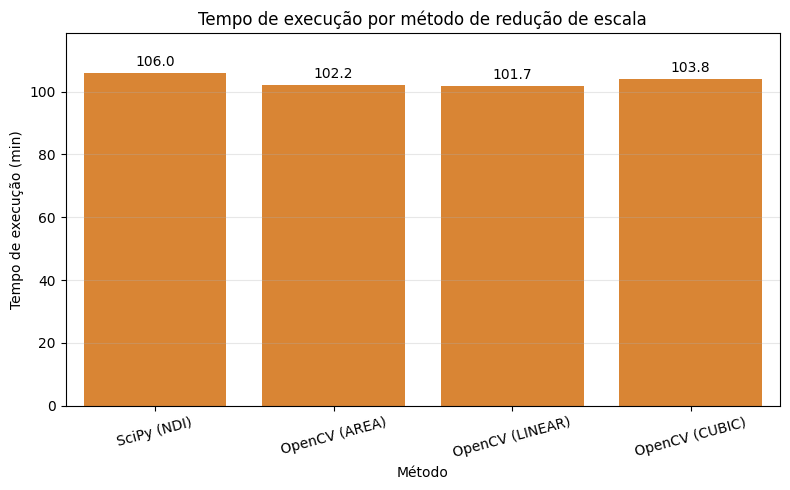

In [120]:
plt.figure(figsize=(8, 5))
ax_down_time = sns.barplot(data=downscale_df, x="metodo", y="tempo_execucao_min", color="#F58518")
max_tempo_downscale = downscale_df["tempo_execucao_min"].max()
ax_down_time.set_ylim(0, max_tempo_downscale * 1.12)
ax_down_time.set_title("Tempo de execução por método de redução de escala")
ax_down_time.set_xlabel("Método")
ax_down_time.set_ylabel("Tempo de execução (min)")
ax_down_time.tick_params(axis="x", rotation=15)
ax_down_time.grid(axis="y", alpha=0.3)
for container in ax_down_time.containers:
    ax_down_time.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

### Dice médio por método

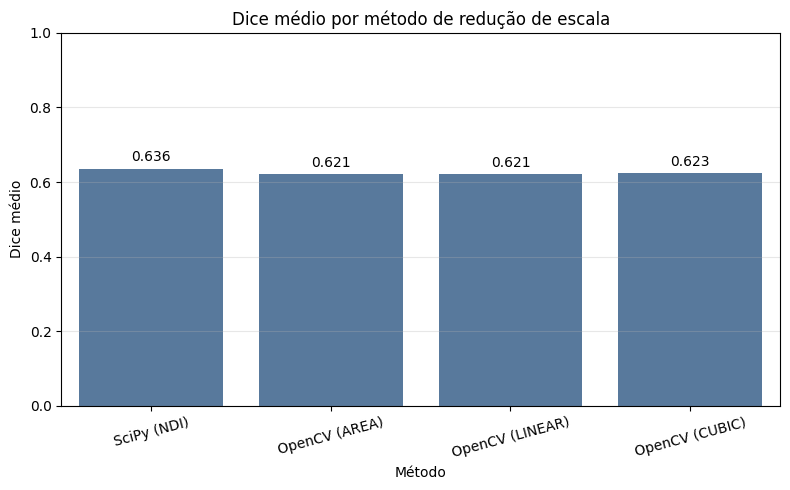

In [121]:
plt.figure(figsize=(8, 5))
ax_down_dice = sns.barplot(data=downscale_df, x="metodo", y="dice_medio", color="#4C78A8")
ax_down_dice.set_ylim(0, 1)
ax_down_dice.set_title("Dice médio por método de redução de escala")
ax_down_dice.set_xlabel("Método")
ax_down_dice.set_ylabel("Dice médio")
ax_down_dice.tick_params(axis="x", rotation=15)
ax_down_dice.grid(axis="y", alpha=0.3)
for container in ax_down_dice.containers:
    ax_down_dice.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

### Sucesso na detecção dos óstios por método

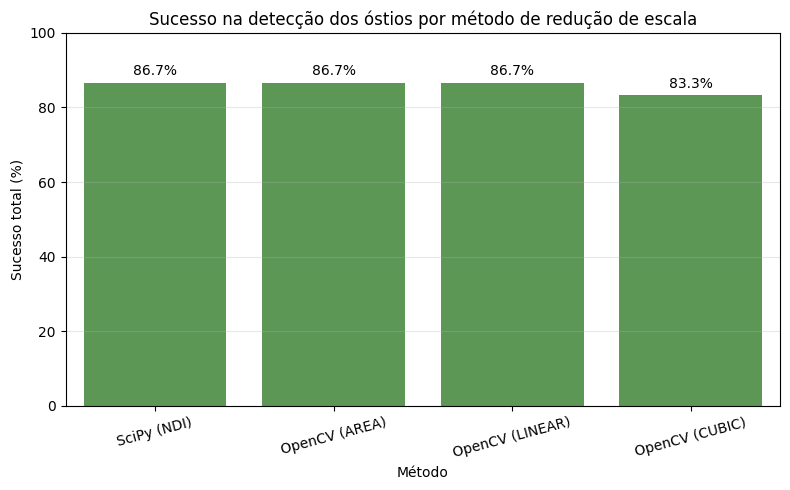

In [122]:
plt.figure(figsize=(8, 5))
ax_down_success = sns.barplot(data=downscale_df, x="metodo", y="sucesso_total_percent", color="#54A24B")
ax_down_success.set_ylim(0, 100)
ax_down_success.set_title("Sucesso na detecção dos óstios por método de redução de escala")
ax_down_success.set_xlabel("Método")
ax_down_success.set_ylabel("Sucesso total (%)")
ax_down_success.tick_params(axis="x", rotation=15)
ax_down_success.grid(axis="y", alpha=0.3)
for container in ax_down_success.containers:
    ax_down_success.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

## Resultados por quantidade de dados de validação

### Dice médio

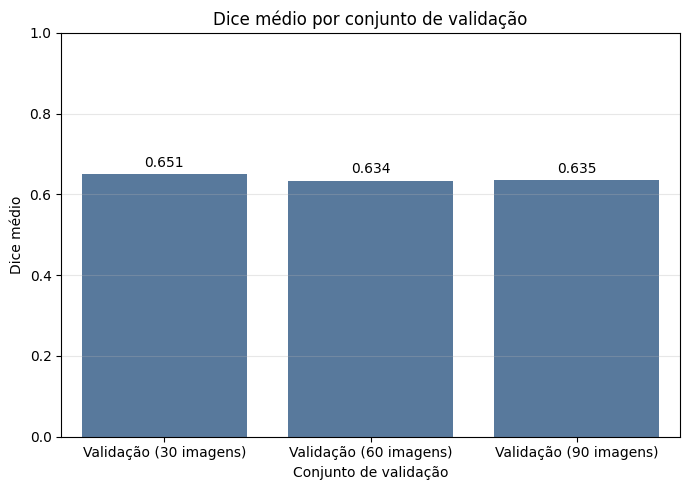

In [123]:
summary_rows = []

for num in num_tests:
    csv_df = dict_val_tests[num]["csv"].copy()
    json_df = dict_val_tests[num]["json"].copy()

    dice_scores = pd.to_numeric(csv_df["dice_artery"], errors="coerce").dropna()
    execution_time_seconds = json_df["execution_info"]["execution_time_seconds"]
    total_success_percent = json_df["results_summary"]["total_success_percent"]

    summary_rows.append(
        {
            "dataset": f"Validação ({num} imagens)",
            "dice_medio": dice_scores.mean(),
            "tempo_execucao_s": execution_time_seconds,
            "tempo_execucao_min": execution_time_seconds / 60,
            "sucesso_total_percent": total_success_percent,
        }
    )

summary_df = pd.DataFrame(summary_rows)

plt.figure(figsize=(7, 5))
ax1 = sns.barplot(data=summary_df, x="dataset", y="dice_medio", color="#4C78A8")
ax1.set_ylim(0, 1)
ax1.set_title("Dice médio por conjunto de validação")
ax1.set_xlabel("Conjunto de validação")
ax1.set_ylabel("Dice médio")
ax1.grid(axis="y", alpha=0.3)
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

### Tempo de execução

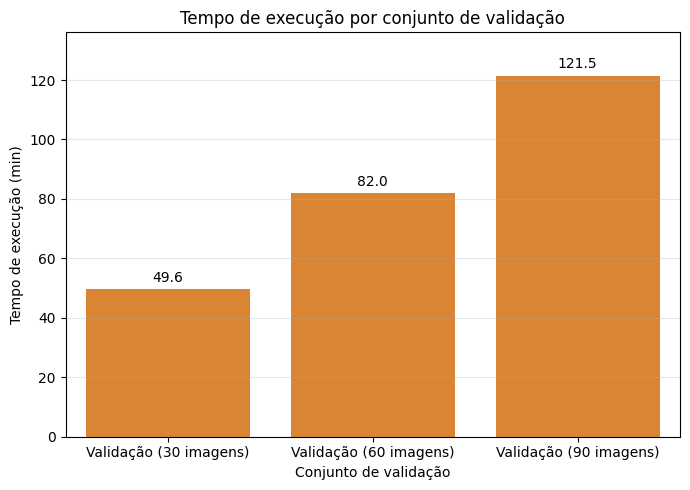

In [124]:
plt.figure(figsize=(7, 5))
ax2 = sns.barplot(data=summary_df, x="dataset", y="tempo_execucao_min", color="#F58518")
max_tempo_val = summary_df["tempo_execucao_min"].max()
ax2.set_ylim(0, max_tempo_val * 1.12)
ax2.set_title("Tempo de execução por conjunto de validação")
ax2.set_xlabel("Conjunto de validação")
ax2.set_ylabel("Tempo de execução (min)")
ax2.grid(axis="y", alpha=0.3)
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

### Sucesso total de detecção de óstios

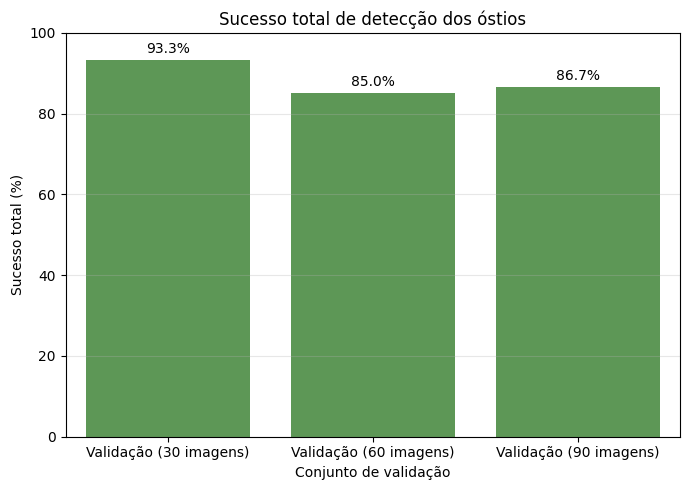

In [125]:
plt.figure(figsize=(7, 5))
ax3 = sns.barplot(data=summary_df, x="dataset", y="sucesso_total_percent", color="#54A24B")
ax3.set_ylim(0, 100)
ax3.set_title("Sucesso total de detecção dos óstios")
ax3.set_xlabel("Conjunto de validação")
ax3.set_ylabel("Sucesso total (%)")
ax3.grid(axis="y", alpha=0.3)
for container in ax3.containers:
    ax3.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

## Resultados por subset: val, train e test

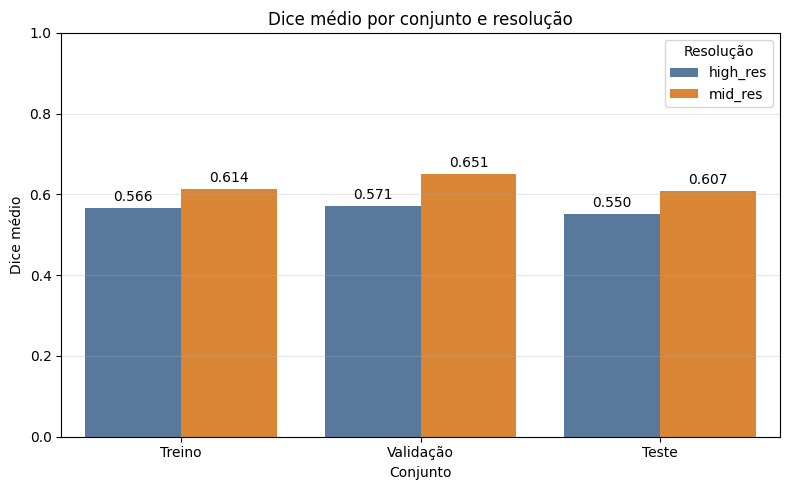

In [126]:
plot_subset_df = subset_summary_df[subset_summary_df["disponivel"]].copy()
plot_subset_df["conjunto"] = plot_subset_df["subset"].map({"train": "Treino", "val": "Validação", "test": "Teste"})

plt.figure(figsize=(8, 5))
ax_subset = sns.barplot(
    data=plot_subset_df,
    x="conjunto",
    y="dice_medio",
    hue="resolucao",
    palette=["#4C78A8", "#F58518"],
)
ax_subset.set_ylim(0, 1)
ax_subset.set_title("Dice médio por conjunto e resolução")
ax_subset.set_xlabel("Conjunto")
ax_subset.set_ylabel("Dice médio")
ax_subset.grid(axis="y", alpha=0.3)
ax_subset.legend(title="Resolução")
for container in ax_subset.containers:
    ax_subset.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

### Tempo de execução por conjunto

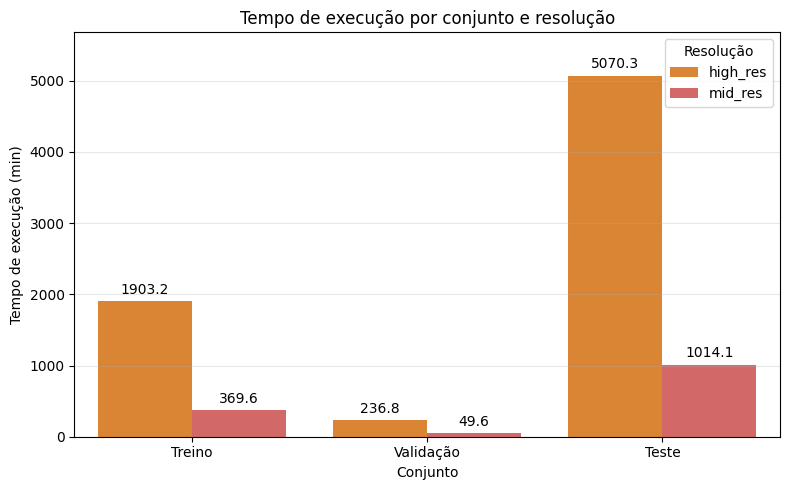

In [127]:
plot_subset_df = subset_summary_df[subset_summary_df["disponivel"]].copy()
plot_subset_df["conjunto"] = plot_subset_df["subset"].map({"train": "Treino", "val": "Validação", "test": "Teste"})

plt.figure(figsize=(8, 5))
ax_subset_time = sns.barplot(
    data=plot_subset_df,
    x="conjunto",
    y="tempo_execucao_min",
    hue="resolucao",
    palette=["#F58518", "#E45756"],
)
max_tempo_subset = plot_subset_df["tempo_execucao_min"].max()
ax_subset_time.set_ylim(0, max_tempo_subset * 1.12 if pd.notna(max_tempo_subset) else 1)
ax_subset_time.set_title("Tempo de execução por conjunto e resolução")
ax_subset_time.set_xlabel("Conjunto")
ax_subset_time.set_ylabel("Tempo de execução (min)")
ax_subset_time.grid(axis="y", alpha=0.3)
ax_subset_time.legend(title="Resolução")
for container in ax_subset_time.containers:
    ax_subset_time.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

### Percentual de óstios detectados com sucesso por conjunto

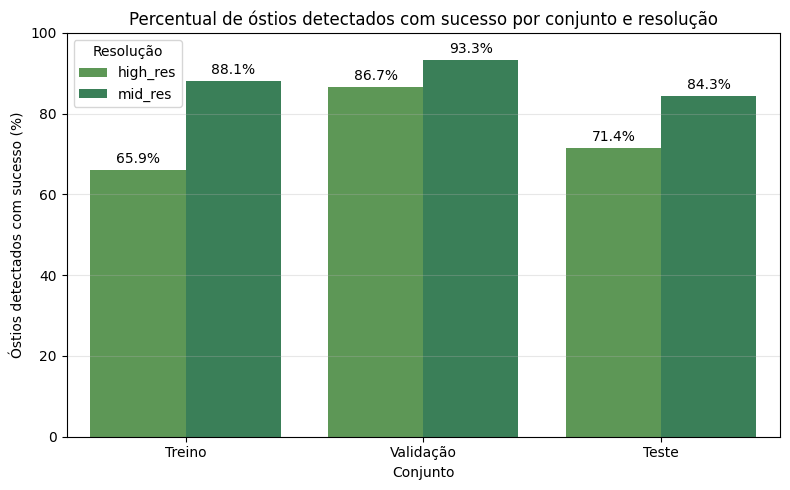

In [128]:
plot_subset_df = subset_summary_df[subset_summary_df["disponivel"]].copy()
plot_subset_df["conjunto"] = plot_subset_df["subset"].map({"train": "Treino", "val": "Validação", "test": "Teste"})

plt.figure(figsize=(8, 5))
ax_subset_success = sns.barplot(
    data=plot_subset_df,
    x="conjunto",
    y="sucesso_total_percent",
    hue="resolucao",
    palette=["#54A24B", "#2E8B57"],
)
ax_subset_success.set_ylim(0, 100)
ax_subset_success.set_title("Percentual de óstios detectados com sucesso por conjunto e resolução")
ax_subset_success.set_xlabel("Conjunto")
ax_subset_success.set_ylabel("Óstios detectados com sucesso (%)")
ax_subset_success.grid(axis="y", alpha=0.3)
ax_subset_success.legend(title="Resolução")
for container in ax_subset_success.containers:
    ax_subset_success.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

## Casos Ruins por Subset

### Função auxiliar para plotagem

In [129]:
def change_status_label_for_plot(status):
    status = str(status)
    if "erro" in status.lower():
        return "óstios não encontrados"
    if "ambos toler" in status.lower() or "ambos corret" in status.lower():
        return "baixo dice score"
    return status.lower()


def plot_bad_cases_by_subset(df_mid, df_high, df_mid_bad, df_high_bad, subset_label):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if df_mid is not None and not df_mid.empty:
        mid_status = df_mid_bad["status"].fillna("sem status").value_counts()
        mid_status.index = mid_status.index.map(change_status_label_for_plot)
        mid_status = mid_status.groupby(level=0).sum()
        sns.barplot(x=mid_status.index, y=mid_status.values, color="#4C78A8", ax=axes[0])
        axes[0].set_xlabel("Status")
        axes[0].set_ylabel("Quantidade de casos")
        axes[0].set_title(f"Distribuição de status dos casos ruins - Mid Res ({subset_label})")
        axes[0].tick_params(axis="x", rotation=45)
        for p in axes[0].patches:
            height = p.get_height()
            axes[0].text(p.get_x() + p.get_width() / 2.0, height, f"{int(height)}", ha="center", va="bottom")
    else:
        axes[0].text(0.5, 0.5, f"Sem dados de {subset_label.lower()} para Mid Res", ha="center", va="center", transform=axes[0].transAxes)
        axes[0].set_title(f"Distribuição de status dos casos ruins - Mid Res ({subset_label})")

    if df_high is not None and not df_high.empty:
        high_status = df_high_bad["status"].fillna("sem status").value_counts()
        high_status.index = high_status.index.map(change_status_label_for_plot)
        high_status = high_status.groupby(level=0).sum()
        sns.barplot(x=high_status.index, y=high_status.values, color="#F58518", ax=axes[1])
        axes[1].set_xlabel("Status")
        axes[1].set_ylabel("Quantidade de casos")
        axes[1].set_title(f"Distribuição de status dos casos ruins - High Res ({subset_label})")
        axes[1].tick_params(axis="x", rotation=45)
        for p in axes[1].patches:
            height = p.get_height()
            axes[1].text(p.get_x() + p.get_width() / 2.0, height, f"{int(height)}", ha="center", va="bottom")
    else:
        axes[1].text(0.5, 0.5, f"Sem dados de {subset_label.lower()} para High Res\n(Em preparação)", ha="center", va="center", transform=axes[1].transAxes, fontsize=11, color="gray")
        axes[1].set_title(f"Distribuição de status dos casos ruins - High Res ({subset_label})")
        axes[1].set_xticks([])
        axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

### Validação (Val)

CASOS RUINS - VALIDAÇÃO (VAL)

Mid Res: 2/30 casos ruins (6.7%)
High Res: 5/30 casos ruins (16.7%)


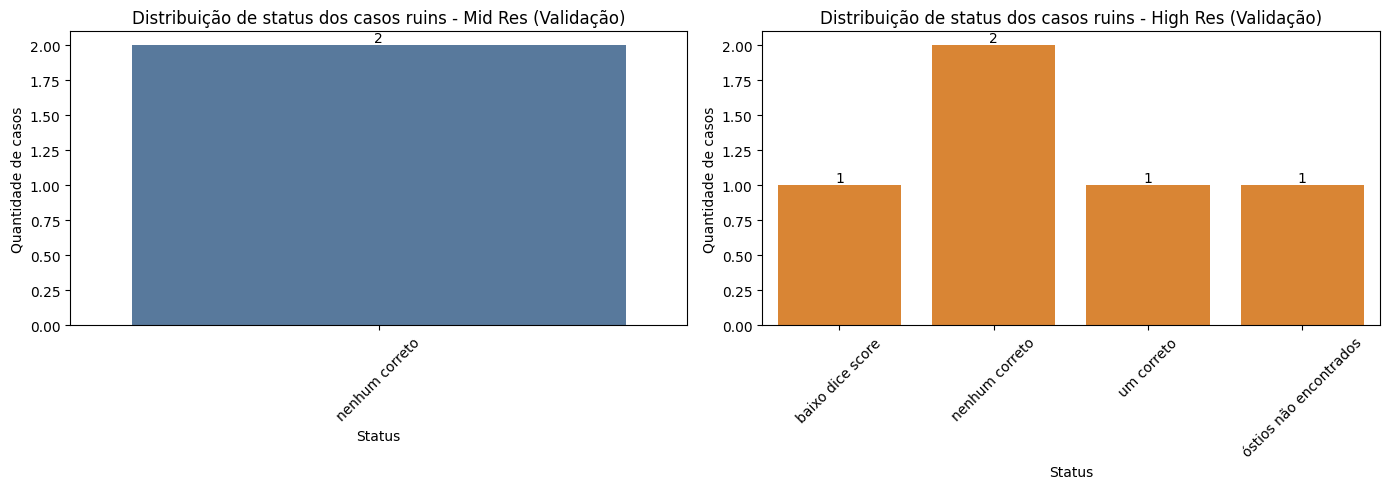

In [130]:
# Carregamento de dados de validação
df_mid_val = load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", "val")
df_high_val = load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", "val")

df_mid_val_bad = get_bad_cases(df_mid_val) if df_mid_val is not None else pd.DataFrame()
df_high_val_bad = get_bad_cases(df_high_val) if df_high_val is not None else pd.DataFrame()

# Resumo de casos ruins para validação
print("="*60)
print("CASOS RUINS - VALIDAÇÃO (VAL)")
print("="*60)
print(f"\nMid Res: {len(df_mid_val_bad)}/{len(df_mid_val)} casos ruins ({100*len(df_mid_val_bad)/len(df_mid_val):.1f}%)" if df_mid_val is not None else "Mid Res: Sem dados")
if df_high_val is not None:
    print(f"High Res: {len(df_high_val_bad)}/{len(df_high_val)} casos ruins ({100*len(df_high_val_bad)/len(df_high_val):.1f}%)")
else:
    print("High Res: Sem dados disponíveis")

# Plotar
plot_bad_cases_by_subset(df_mid_val, df_high_val, df_mid_val_bad, df_high_val_bad, "Validação")

### Treino (Train)

CASOS RUINS - TREINO (TRAIN)

Mid Res: 60/270 casos ruins (22.2%)
High Res: 99/270 casos ruins (36.7%)


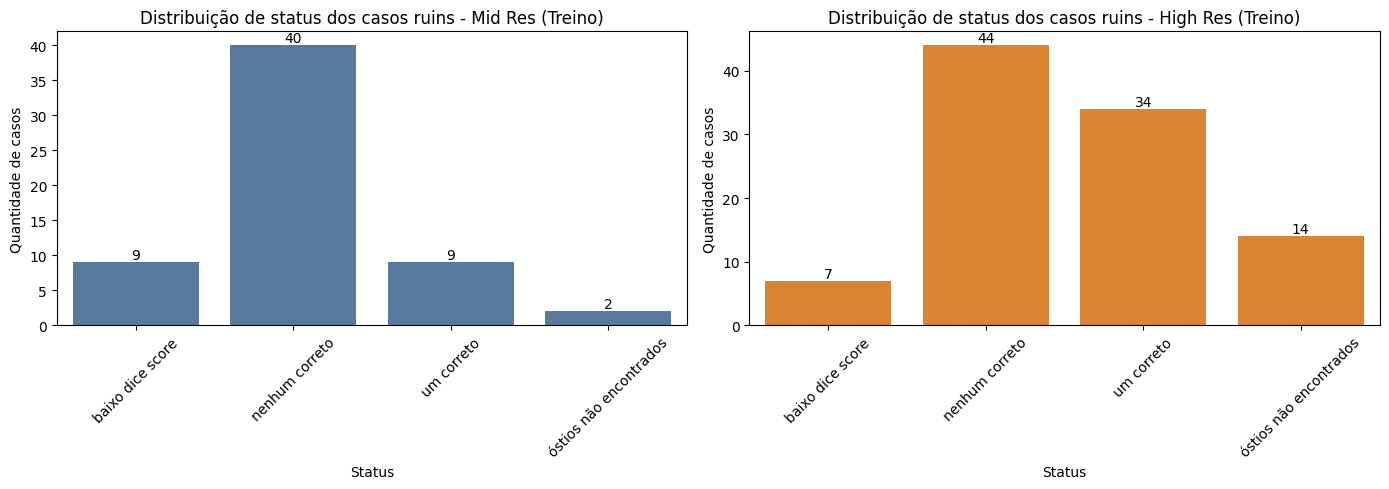

In [131]:
# Carregamento de dados de treino
df_mid_train = load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", "train")
df_high_train = load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", "train")

df_mid_train_bad = get_bad_cases(df_mid_train) if df_mid_train is not None else pd.DataFrame()
df_high_train_bad = get_bad_cases(df_high_train) if df_high_train is not None else pd.DataFrame()

# Resumo de casos ruins para treino
print("="*60)
print("CASOS RUINS - TREINO (TRAIN)")
print("="*60)
print(f"\nMid Res: {len(df_mid_train_bad)}/{len(df_mid_train)} casos ruins ({100*len(df_mid_train_bad)/len(df_mid_train):.1f}%)" if df_mid_train is not None else "Mid Res: Sem dados")
if df_high_train is not None:
    print(f"High Res: {len(df_high_train_bad)}/{len(df_high_train)} casos ruins ({100*len(df_high_train_bad)/len(df_high_train):.1f}%)")
else:
    print("High Res: Sem dados disponíveis")

# Plotar
plot_bad_cases_by_subset(df_mid_train, df_high_train, df_mid_train_bad, df_high_train_bad, "Treino")

### Teste (Test)

CASOS RUINS - TESTE (TEST)

Mid Res: 137/700 casos ruins (19.6%)
High Res: 227/700 casos ruins (32.4%)


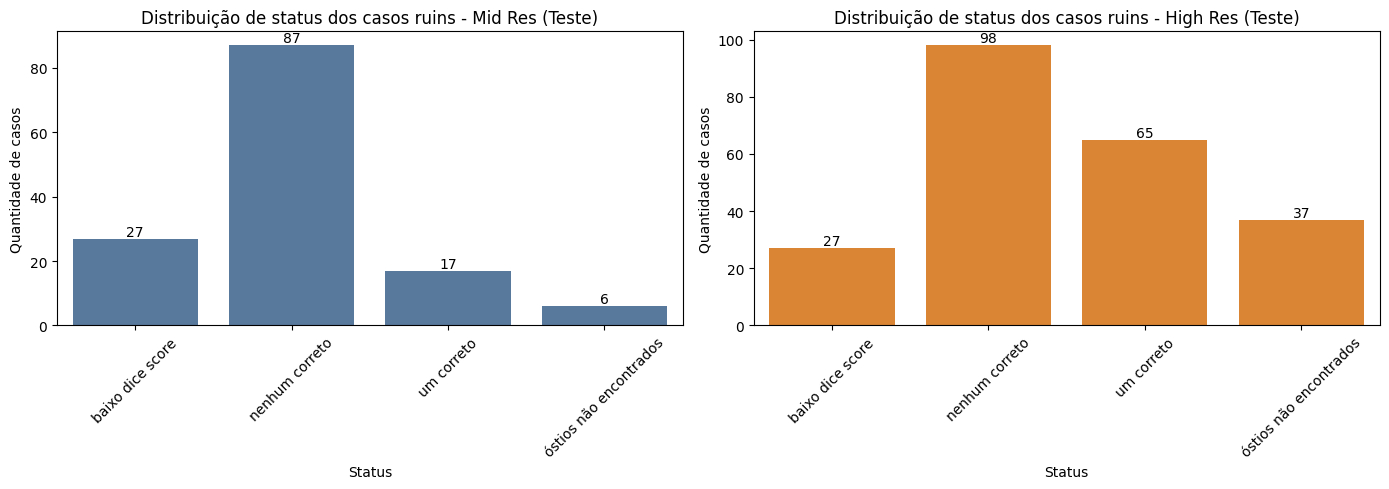

In [132]:
# Carregamento de dados de teste
df_mid_test = load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", "test")
df_high_test = load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", "test")

df_mid_test_bad = get_bad_cases(df_mid_test) if df_mid_test is not None else pd.DataFrame()
df_high_test_bad = get_bad_cases(df_high_test) if df_high_test is not None else pd.DataFrame()

# Resumo de casos ruins para teste
print("="*60)
print("CASOS RUINS - TESTE (TEST)")
print("="*60)
print(f"\nMid Res: {len(df_mid_test_bad)}/{len(df_mid_test)} casos ruins ({100*len(df_mid_test_bad)/len(df_mid_test):.1f}%)" if df_mid_test is not None else "Mid Res: Sem dados")
if df_high_test is not None:
    print(f"High Res: {len(df_high_test_bad)}/{len(df_high_test)} casos ruins ({100*len(df_high_test_bad)/len(df_high_test):.1f}%)")
else:
    print("High Res: Sem dados disponíveis")

# Plotar
plot_bad_cases_by_subset(df_mid_test, df_high_test, df_mid_test_bad, df_high_test_bad, "Teste")

## Distribuição de Dice Score por Subset

### Função auxiliar para plotagem

In [133]:
def plot_dice_distribution_by_subset(df_mid, df_high, subset_label):
    """
    Plota a distribuição do Dice Score para um subset específico.

    Parameters:
    - df_mid, df_high: DataFrames com dados originais
    - subset_label: Rótulo do subset em português (ex: "Treino", "Teste", "Validação")
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Mid Res
    if df_mid is not None and not df_mid.empty:
        dice_scores_mid = pd.to_numeric(df_mid['dice_artery'], errors='coerce').dropna()
        mu_mid = dice_scores_mid.mean()
        sigma_mid = dice_scores_mid.std()

        sns.histplot(dice_scores_mid, bins=20, kde=True, color='skyblue', edgecolor='black', ax=axes[0])
        axes[0].axvline(mu_mid, color='red', linestyle='-', linewidth=2, label=f'Média = {mu_mid:.3f}')
        axes[0].axvline(mu_mid - sigma_mid, color='orange', linestyle='--', linewidth=2, label=f'-1σ = {mu_mid - sigma_mid:.3f}')
        axes[0].axvline(mu_mid + sigma_mid, color='orange', linestyle='--', linewidth=2, label=f'+1σ = {mu_mid + sigma_mid:.3f}')
        axes[0].axvspan(mu_mid - sigma_mid, mu_mid + sigma_mid, color='orange', alpha=0.15, label='Faixa ±1σ')
        axes[0].set_title(f'Distribuição dos Dice Scores - Mid Res ({subset_label})')
        axes[0].set_xlabel('Dice Score')
        axes[0].set_ylabel('Frequência')
        axes[0].grid(axis='y', alpha=0.3)
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, f'Sem dados de {subset_label.lower()} para Mid Res', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title(f'Distribuição dos Dice Scores - Mid Res ({subset_label})')

    # High Res
    if df_high is not None and not df_high.empty:
        dice_scores_high = pd.to_numeric(df_high['dice_artery'], errors='coerce').dropna()
        mu_high = dice_scores_high.mean()
        sigma_high = dice_scores_high.std()

        sns.histplot(dice_scores_high, bins=20, kde=True, color='lightgreen', edgecolor='black', ax=axes[1])
        axes[1].axvline(mu_high, color='red', linestyle='-', linewidth=2, label=f'Média = {mu_high:.3f}')
        axes[1].axvline(mu_high - sigma_high, color='orange', linestyle='--', linewidth=2, label=f'-1σ = {mu_high - sigma_high:.3f}')
        axes[1].axvline(mu_high + sigma_high, color='orange', linestyle='--', linewidth=2, label=f'+1σ = {mu_high + sigma_high:.3f}')
        axes[1].axvspan(mu_high - sigma_high, mu_high + sigma_high, color='orange', alpha=0.15, label='Faixa ±1σ')
        axes[1].set_title(f'Distribuição dos Dice Scores - High Res ({subset_label})')
        axes[1].set_xlabel('Dice Score')
        axes[1].set_ylabel('Frequência')
        axes[1].grid(axis='y', alpha=0.3)
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, f'Sem dados de {subset_label.lower()} para High Res\n(Em preparação)', ha='center', va='center', transform=axes[1].transAxes, fontsize=11, color='gray')
        axes[1].set_title(f'Distribuição dos Dice Scores - High Res ({subset_label})')
        axes[1].set_xticks([])
        axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()


### Validação (Val)

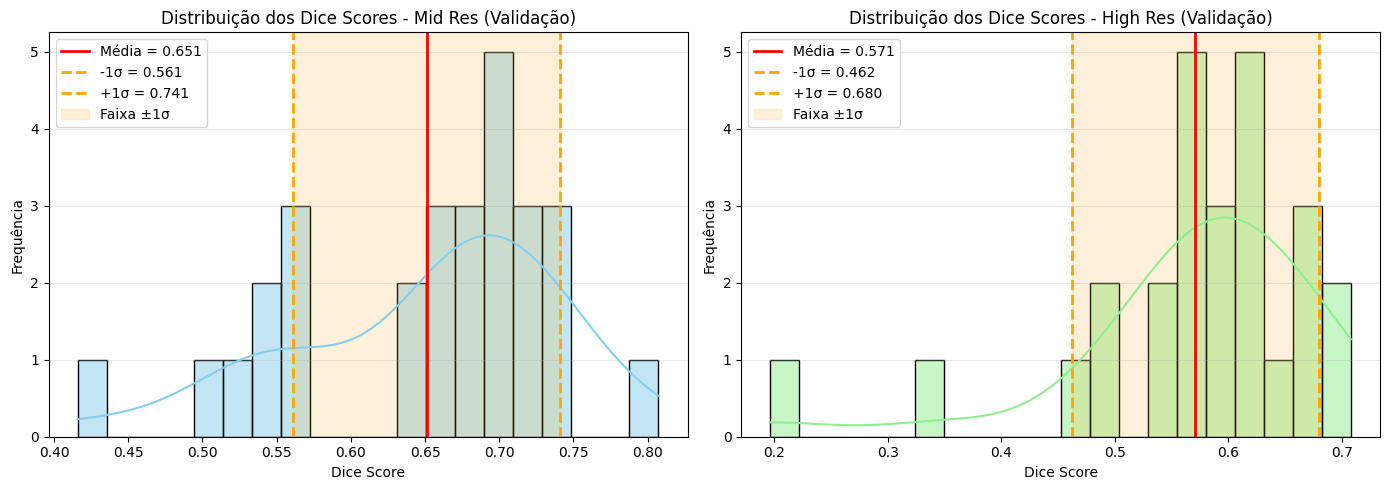

In [134]:
plot_dice_distribution_by_subset(df_mid_val, df_high_val, "Validação")

### Treino (Train)

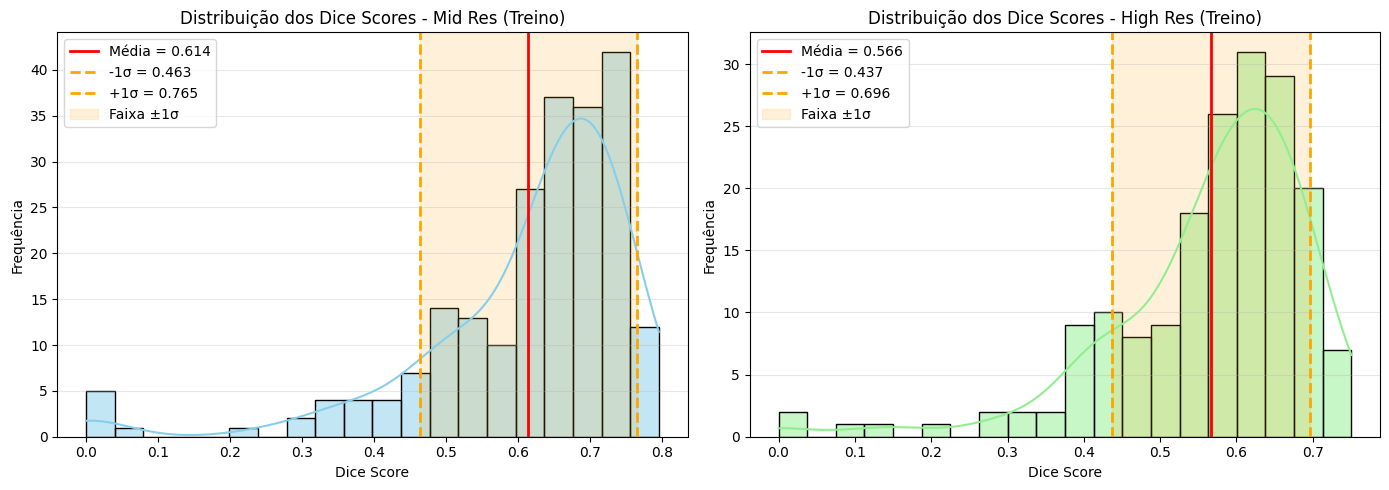

In [135]:
plot_dice_distribution_by_subset(df_mid_train, df_high_train, "Treino")

### Teste (Test)

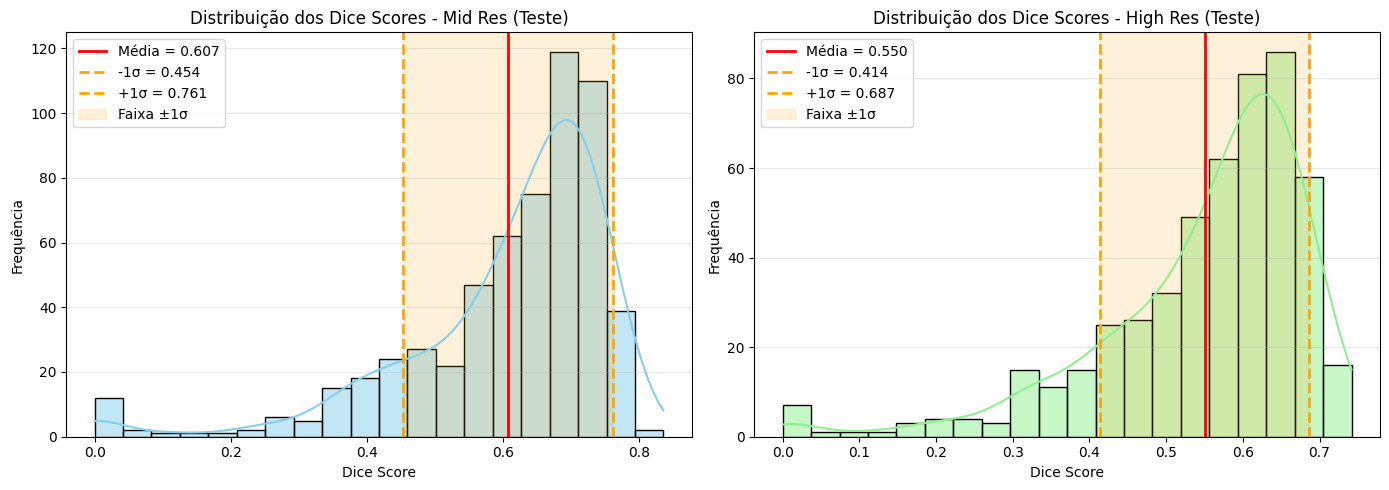

In [136]:
plot_dice_distribution_by_subset(df_mid_test, df_high_test, "Teste")

## Comparação: Métodos de IA vs Método Matemático

Esta seção compara os Dice Scores dos métodos de IA com o pipeline matemático para **Mid Res** e **High Res**.

- IA: resultados em ../output/ia_results (todos os CSVs disponíveis).
- Matemático: ostios_{train,val,test}_summary.csv de Mid Res e High Res.
- Filtro de comparação: no método matemático, são considerados apenas os IMG_ID que também aparecem nos métodos de IA (por resolução-alvo).
- Comparação agregada por método (média, desvio e quartis).

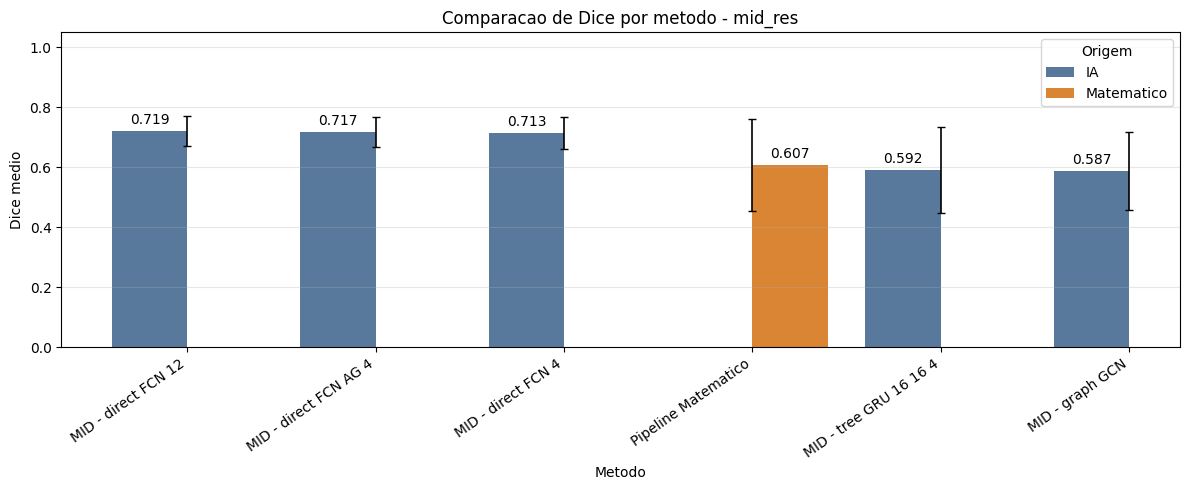

In [147]:
if comparison_agg_df.empty:
    raise ValueError("comparison_agg_df está vazio. Execute a célula de carregamento na seção 'Carregamento de dados'.")

plot_comparison_bar_by_resolution(comparison_agg_df, "mid_res")

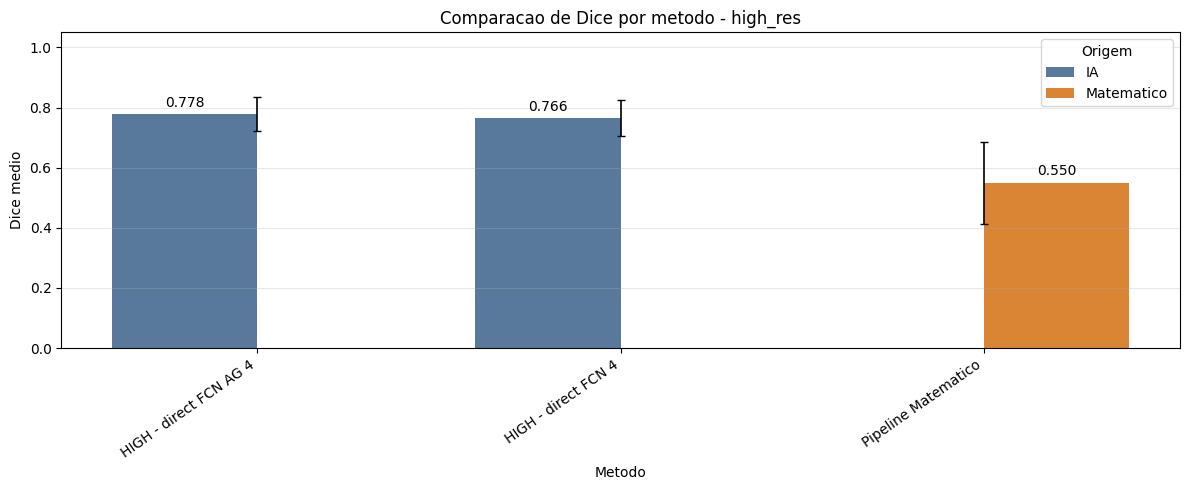

In [148]:
if comparison_agg_df.empty:
    raise ValueError("comparison_agg_df está vazio. Execute a célula de carregamento na seção 'Carregamento de dados'.")

plot_comparison_bar_by_resolution(comparison_agg_df, "high_res")